In [16]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    roc_auc_score
)
from sklearn.linear_model import LogisticRegression

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

# Set device
device = "mps"   # or "cpu"
print("Using device:", device)

# IMPORTANT: Name this world
WORLD_NAME = "Fair"


Using: mps


In [17]:
def simulate_easy_fair_world(n_samples=10000):
    race = np.random.choice([0,1,2], size=n_samples, p=[0.6,0.25,0.15])
    gender = np.random.choice([0,1], size=n_samples)
    age = np.random.normal(50, 10, n_samples).clip(18, 90)

    # 20% prevalence
    diabetes = np.random.binomial(1, 0.20, size=n_samples)

    # non-diabetic glucose/HbA1c
    glucose_non = np.random.normal(95, 8, n_samples)
    hba1c_non   = np.random.normal(5.3, 0.25, n_samples)

    # diabetic glucose/HbA1c
    glucose_diab = np.random.normal(160, 20, n_samples)
    hba1c_diab   = np.random.normal(7.0, 0.6, n_samples)

    glucose = np.where(diabetes==1, glucose_diab, glucose_non)
    hba1c   = np.where(diabetes==1, hba1c_diab, hba1c_non)

    # small unbiased noise
    glucose_meas = glucose + np.random.normal(0, 5, n_samples)
    hba1c_meas   = hba1c + np.random.normal(0, 0.15, n_samples)

    return pd.DataFrame({
        "race": race,
        "gender": gender,
        "age": age,
        "glucose_measured": glucose_meas,
        "hba1c_measured": hba1c_meas,
        "diabetes_label": diabetes
    })


In [33]:
df = simulate_easy_fair_world(10000)

feature_cols = ["glucose_measured", "hba1c_measured", "age"]
X = df[feature_cols]
y = df["diabetes_label"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Train prevalence:", y_train.mean())
print("Test prevalence:", y_test.mean())

# Scale numeric features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)


Train prevalence: 0.197875
Test prevalence: 0.199


In [20]:
X_train_t = torch.tensor(X_train_scaled, dtype=torch.float32).to(device)
y_train_t = torch.tensor(y_train.values, dtype=torch.long).to(device)

X_test_t = torch.tensor(X_test_scaled, dtype=torch.float32).to(device)
y_test_t = torch.tensor(y_test.values, dtype=torch.long).to(device)

train_loader = DataLoader(TensorDataset(X_train_t, y_train_t), batch_size=32, shuffle=True)
test_loader  = DataLoader(TensorDataset(X_test_t, y_test_t), batch_size=32, shuffle=False)


In [23]:
class MLP(nn.Module):
    def __init__(self):
        super().__init__()
        self.layers = nn.Sequential(
            nn.Linear(3, 16),
            nn.ReLU(),
            nn.Linear(16, 16),
            nn.ReLU(),
            nn.Linear(16, 2)
        )

    def forward(self, x):
        return self.layers(x)


In [21]:
def train_epoch(model, train_dataloader, optimizer, loss_fn):
    losses = []
    correct_predictions = 0

    for features, labels in train_dataloader:
        output = model(features)
        optimizer.zero_grad()
        loss = loss_fn(output, labels)
        loss.backward()
        optimizer.step()

        losses.append(loss.item())
        predicted = output.argmax(dim=1)
        correct_predictions += (predicted == labels).sum().item()

    acc = 100 * correct_predictions / len(train_dataloader.dataset)
    return np.mean(losses), acc


def evaluate(model, dataloader, loss_fn):
    losses = []
    correct_predictions = 0

    with torch.no_grad():
        for features, labels in dataloader:
            output = model(features)
            loss = loss_fn(output, labels)
            losses.append(loss.item())
            predicted = output.argmax(dim=1)
            correct_predictions += (predicted == labels).sum().item()

    acc = 100 * correct_predictions / len(dataloader.dataset)
    return np.mean(losses), acc


def train(model, train_dataloader, val_dataloader, optimizer, n_epochs, loss_fn):
    train_losses, val_losses = [], []
    train_accs, val_accs = [], []

    for epoch in range(n_epochs):
        tr_loss, tr_acc = train_epoch(model, train_dataloader, optimizer, loss_fn)
        val_loss, val_acc = evaluate(model, val_dataloader, loss_fn)

        train_losses.append(tr_loss)
        val_losses.append(val_loss)
        train_accs.append(tr_acc)
        val_accs.append(val_acc)

        print(f"Epoch {epoch+1}/{n_epochs}: "
              f"train_loss={tr_loss:.4f}, train_acc={tr_acc:.2f}, "
              f"val_loss={val_loss:.4f}, val_acc={val_acc:.2f}")

    return train_losses, val_losses, train_accs, val_accs


def plot(train_losses, val_losses, train_accs, val_accs, title):
    plt.figure()
    plt.plot(train_losses)
    plt.plot(val_losses)
    plt.legend(["train_loss", "val_loss"])
    plt.title(title + " Loss")

    plt.figure()
    plt.plot(train_accs)
    plt.plot(val_accs)
    plt.legend(["train_acc", "val_acc"])
    plt.title(title + " Accuracy")


Epoch 1/20: train_loss=0.1490, train_acc=95.64, val_loss=0.0102, val_acc=99.85
Epoch 2/20: train_loss=0.0084, train_acc=99.76, val_loss=0.0053, val_acc=99.85
Epoch 3/20: train_loss=0.0063, train_acc=99.84, val_loss=0.0040, val_acc=99.90
Epoch 4/20: train_loss=0.0057, train_acc=99.81, val_loss=0.0040, val_acc=99.90
Epoch 5/20: train_loss=0.0056, train_acc=99.84, val_loss=0.0034, val_acc=99.95
Epoch 6/20: train_loss=0.0053, train_acc=99.81, val_loss=0.0032, val_acc=99.95
Epoch 7/20: train_loss=0.0052, train_acc=99.83, val_loss=0.0035, val_acc=99.95
Epoch 8/20: train_loss=0.0052, train_acc=99.81, val_loss=0.0034, val_acc=99.95
Epoch 9/20: train_loss=0.0050, train_acc=99.83, val_loss=0.0039, val_acc=99.90
Epoch 10/20: train_loss=0.0049, train_acc=99.80, val_loss=0.0029, val_acc=99.95
Epoch 11/20: train_loss=0.0051, train_acc=99.85, val_loss=0.0037, val_acc=99.90
Epoch 12/20: train_loss=0.0049, train_acc=99.81, val_loss=0.0037, val_acc=99.90
Epoch 13/20: train_loss=0.0049, train_acc=99.81, 

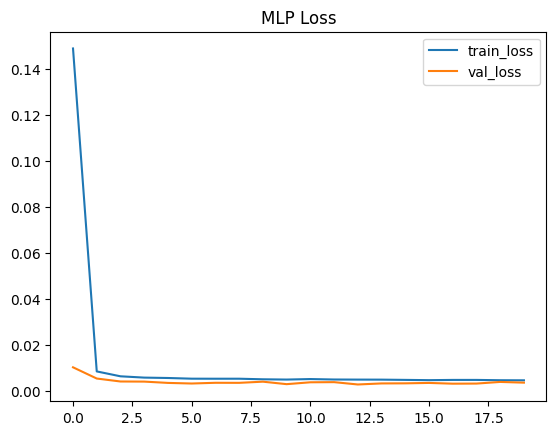

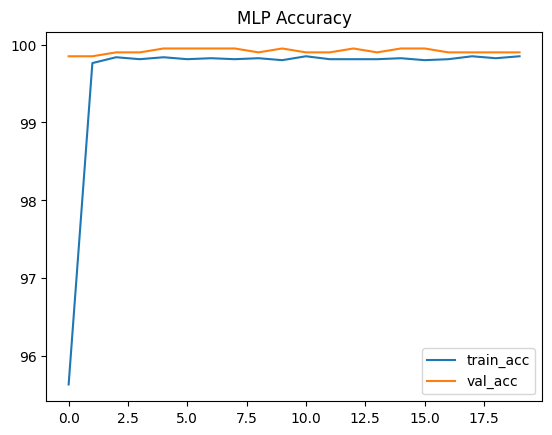

In [34]:
model = MLP().to(device)
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

train_losses, val_losses, train_accs, val_accs = train(
    model, train_loader, test_loader, optimizer, 20, loss_fn
)

plot(train_losses, val_losses, train_accs, val_accs, "MLP")


In [35]:
model.eval()
with torch.no_grad():
    outputs_test = model(X_test_t)
    mlp_pred = outputs_test.argmax(dim=1).cpu().numpy()


In [36]:
lr = LogisticRegression(max_iter=1000)
lr.fit(X_train, y_train)

lr_pred = lr.predict(X_test)
lr_probs = lr.predict_proba(X_test)[:,1]

print("LR accuracy:", accuracy_score(y_test, lr_pred))
print("LR AUC:", roc_auc_score(y_test, lr_probs))


LR accuracy: 0.998
LR AUC: 0.9995702607921004


In [37]:
def fairness_by_group(y_true, y_pred, group_values):
    results = {}
    for g in sorted(group_values.unique()):
        mask = (group_values == g)

        tn, fp, fn, tp = confusion_matrix(
            y_true[mask], y_pred[mask], labels=[0,1]
        ).ravel()

        results[g] = {
            "FPR": fp/(fp+tn) if (fp+tn)>0 else 0,
            "FNR": fn/(fn+tp) if (fn+tp)>0 else 0,
            "TPR": tp/(tp+fn) if (tp+fn)>0 else 0,
            "TNR": tn/(tn+fp) if (tn+fp)>0 else 0
        }
    return pd.DataFrame(results).T


In [38]:
# LR
lr_race_fairness = fairness_by_group(y_test, lr_pred, df.loc[X_test.index, "race"])
lr_gender_fairness = fairness_by_group(y_test, lr_pred, df.loc[X_test.index, "gender"])

# MLP
mlp_race_fairness = fairness_by_group(y_test, mlp_pred, df.loc[X_test.index, "race"])
mlp_gender_fairness = fairness_by_group(y_test, mlp_pred, df.loc[X_test.index, "gender"])

print("=== LR Fairness: RACE ===")
print(lr_race_fairness)
print("\n=== LR Fairness: GENDER ===")
print(lr_gender_fairness)

print("\n=== MLP Fairness: RACE ===")
print(mlp_race_fairness)
print("\n=== MLP Fairness: GENDER ===")
print(mlp_gender_fairness)


=== LR Fairness: RACE ===
   FPR       FNR       TPR  TNR
0  0.0  0.007812  0.992188  1.0
1  0.0  0.011494  0.988506  1.0
2  0.0  0.018182  0.981818  1.0

=== LR Fairness: GENDER ===
   FPR       FNR       TPR  TNR
0  0.0  0.019417  0.980583  1.0
1  0.0  0.000000  1.000000  1.0

=== MLP Fairness: RACE ===
        FPR       FNR       TPR       TNR
0  0.197095  0.765625  0.234375  0.802905
1  0.201511  0.896552  0.103448  0.798489
2  0.157676  0.745455  0.254545  0.842324

=== MLP Fairness: GENDER ===
        FPR       FNR       TPR       TNR
0  0.188986  0.791262  0.208738  0.811014
1  0.195517  0.791667  0.208333  0.804483


In [39]:
def compute_equal_opportunity(fairness_df):
    return float(fairness_df["TPR"].max() - fairness_df["TPR"].min())


In [40]:
EO_LR_gender = compute_equal_opportunity(lr_gender_fairness)
EO_LR_race   = compute_equal_opportunity(lr_race_fairness)

EO_MLP_gender = compute_equal_opportunity(mlp_gender_fairness)
EO_MLP_race   = compute_equal_opportunity(mlp_race_fairness)

print("EO (LR) Gender:", EO_LR_gender)
print("EO (LR) Race:", EO_LR_race)
print("EO (MLP) Gender:", EO_MLP_gender)
print("EO (MLP) Race:", EO_MLP_race)


EO (LR) Gender: 0.01941747572815533
EO (LR) Race: 0.010369318181818188
EO (MLP) Gender: 0.0004045307443365509
EO (MLP) Race: 0.15109717868338557


In [41]:
fair_world_summary = {
    "world_name": WORLD_NAME,
    "LR_accuracy": accuracy_score(y_test, lr_pred),
    "LR_AUROC": roc_auc_score(y_test, lr_probs),
    "LR_EO_gender": EO_LR_gender,
    "LR_EO_race": EO_LR_race,
    "MLP_accuracy": accuracy_score(y_test, mlp_pred),
    "MLP_EO_gender": EO_MLP_gender,
    "MLP_EO_race": EO_MLP_race
}

fair_world_summary


{'world_name': 'Fair',
 'LR_accuracy': 0.998,
 'LR_AUROC': 0.9995702607921004,
 'LR_EO_gender': 0.01941747572815533,
 'LR_EO_race': 0.010369318181818188,
 'MLP_accuracy': 0.6885,
 'MLP_EO_gender': 0.0004045307443365509,
 'MLP_EO_race': 0.15109717868338557}